# Visualización Narrativa

matplotlib o seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker # formatear eje con $, %, K, M, etc..
import seaborn as sns

#Estilo base
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

#Configurar matplot
plt.rcParams['figure.dpi']      =110
plt.rcParams['axes.spines.top']      =False
plt.rcParams['axes.spines.right']      =False
plt.rcParams['axes.titlesize']      =13
plt.rcParams['axes.titleweight']      ='bold'

In [3]:
#Leer el csv
df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')

df.head(3)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.0,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3,0.0,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.62,2,0.0,6.8714


In [4]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


## Analisis Univariado

<Axes: xlabel='Profit', ylabel='Count'>

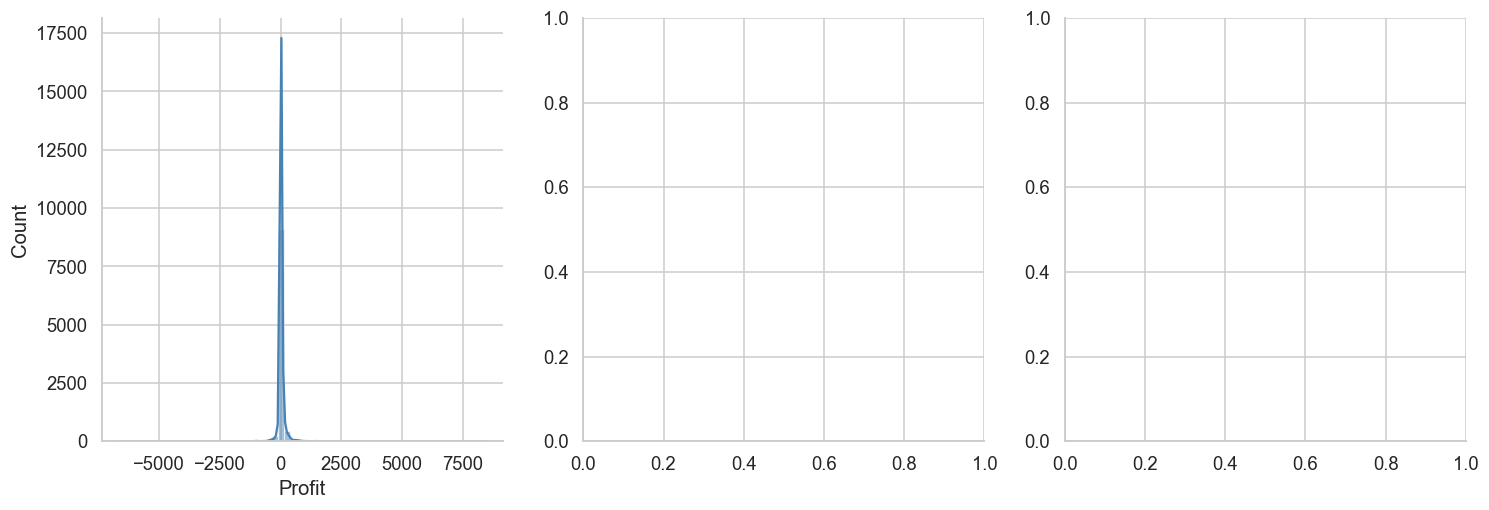

In [5]:
#Como se comporta la distribucion de los datos de Profit
fig, axes = plt.subplots(1, 3, figsize=(16, 5))


sns.histplot(data=df, x='Profit', bins=60, kde=True, color='steelblue', ax=axes[0])



C:\Users\JORGE\AppData\Local\Temp\ipykernel_13224\4102911397.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


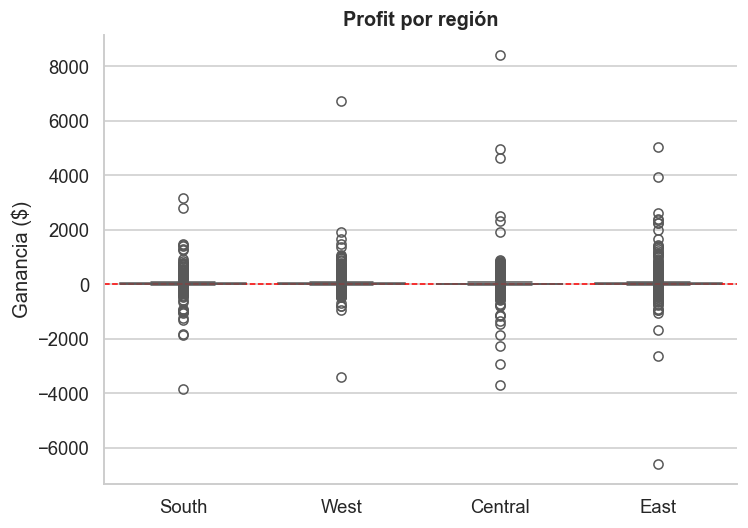

In [6]:
#Boxplot de Profit por Region

plt.figure(figsize=(7,5))
sns.boxplot(
    data=df, x='Region', y='Profit', palette='Set2'
)

plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Profit por región')
plt.xlabel('')
plt.ylabel('Ganancia ($)')
plt.tight_layout()
plt.show()

C:\Users\JORGE\AppData\Local\Temp\ipykernel_13224\3722554318.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Region', y='Profit', palette='muted', errorbar='sd')


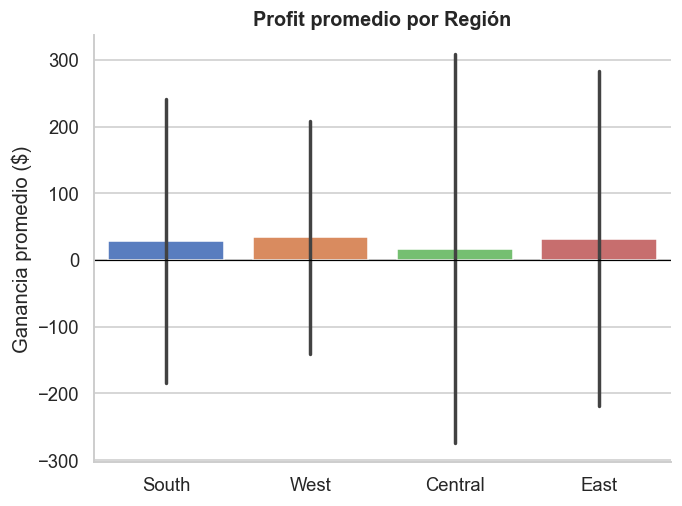

In [7]:
#Revisamos Profit promedio por Región

plt.Figure(figsize=(8, 5))

sns.barplot(data=df, x='Region', y='Profit', palette='muted', errorbar='sd')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Profit promedio por Región')
plt.xlabel('')
plt.ylabel('Ganancia promedio ($)')
plt.tight_layout()
plt.show()

C:\Users\JORGE\AppData\Local\Temp\ipykernel_13224\795070375.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_envio.index, y=ventas_envio.values, palette='Set2')


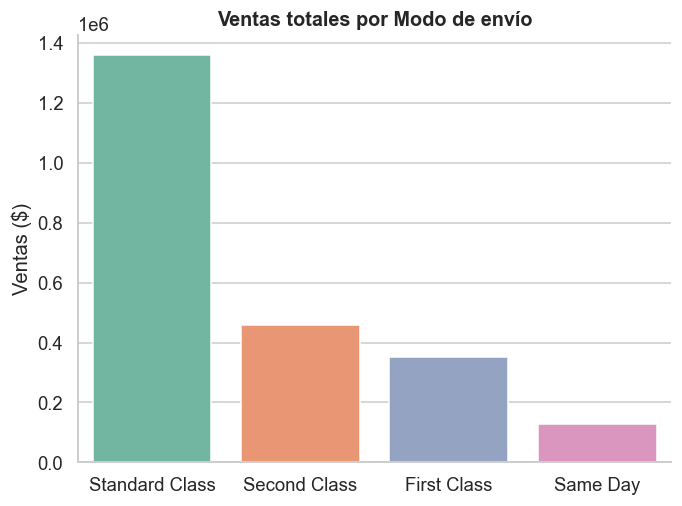

In [8]:
#Ventas totales por ship Mode (modo de envío:)

plt.Figure(figsize=(8, 5))

ventas_envio = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)

sns.barplot(x=ventas_envio.index, y=ventas_envio.values, palette='Set2')
plt.title('Ventas totales por Modo de envío')
plt.xlabel('')
plt.ylabel('Ventas ($)')
plt.tight_layout()
plt.show()

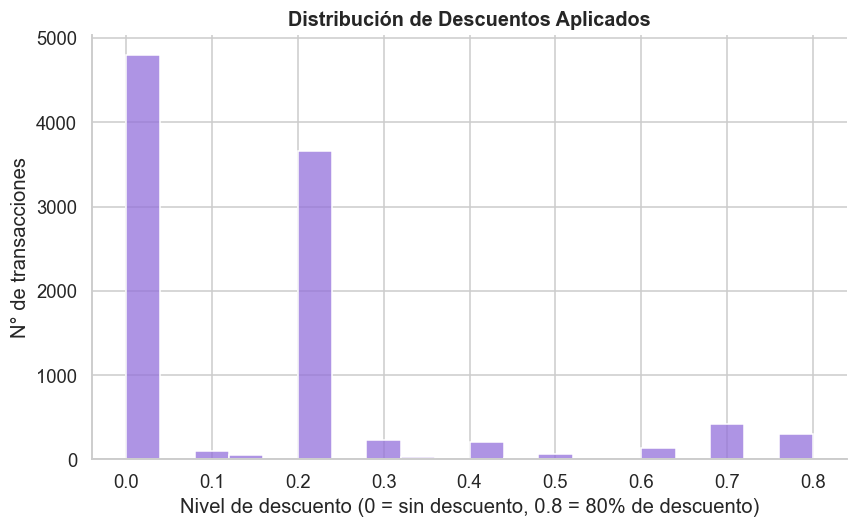

In [9]:
#Hsitograma: Distribución de discount (Descuento en el dataset)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Discount', bins=20, color='mediumpurple')
plt.title('Distribución de Descuentos Aplicados')
plt.xlabel('Nivel de descuento (0 = sin descuento, 0.8 = 80% de descuento)')
plt.ylabel('N° de transacciones')
plt.tight_layout()
plt.show()

Los descuento aparecen en valores discretos: %,

Existe un pico dominante en en 0% de descuento, la mayoría de transacciones no tienen ningún descuento.

Existen descuentos de 40%, 50%, 60%, 70% y hasta 80%.


C:\Users\JORGE\AppData\Local\Temp\ipykernel_13224\2212653019.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Region', order=orden_reg, palette='Set2')


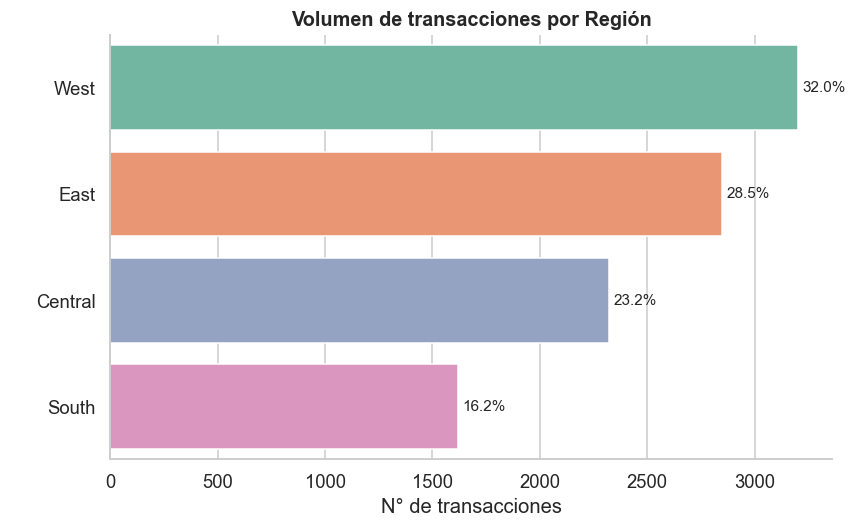

In [10]:
#Graficar volumen de transacciones por region
plt.figure(figsize=(8,5))
orden_reg = df['Region'].value_counts().index
sns.countplot(data=df, y='Region', order=orden_reg, palette='Set2')

ax = plt.gca()
total = len(df)
for p in ax.patches:
    pct = p.get_width() / total * 100
    ax.text(p.get_width() + 20, p.get_y() + p.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=10)

plt.title('Volumen de transacciones por Región')
plt.xlabel('N° de transacciones')
plt.ylabel(' ')
plt.tight_layout()



plt.show()

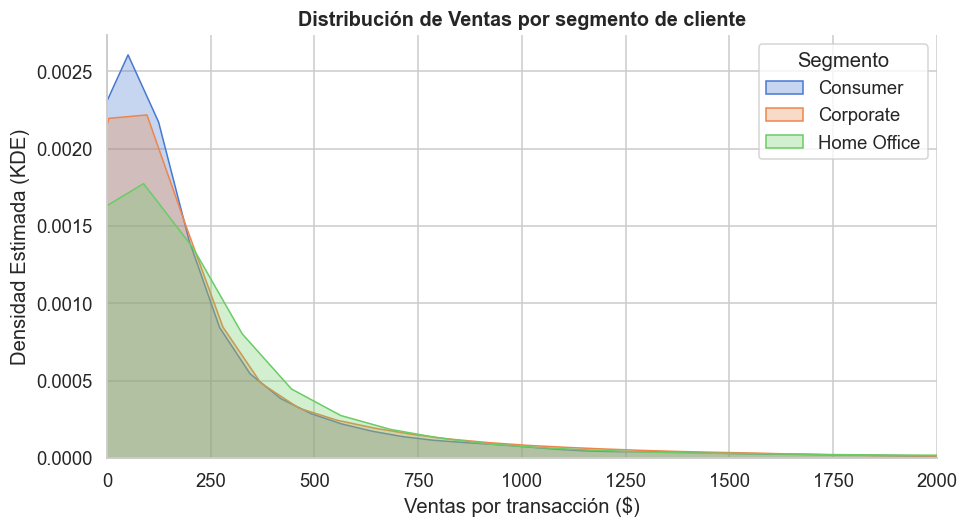

In [11]:
#Vamos a revisar la dsitribuciópn de Sales (ventas) por Segmento de cliente

plt.figure(figsize=(9,5))
for segmento in df['Segment'].unique():
    datos = df[df['Segment'] == segmento]['Sales']
    sns.kdeplot(datos, label=segmento, fill=True, alpha=0.3)

plt.xlim(0, 2000)
plt.title('Distribución de Ventas por segmento de cliente')
plt.xlabel('Ventas por transacción ($)')
plt.ylabel('Densidad Estimada (KDE)')
plt.legend(title='Segmento')
plt.tight_layout()


plt.show()

## Análisis Bivariado

Coeficiente de Pearson:

Un valor positivo

Un valor negativo

Y Cero

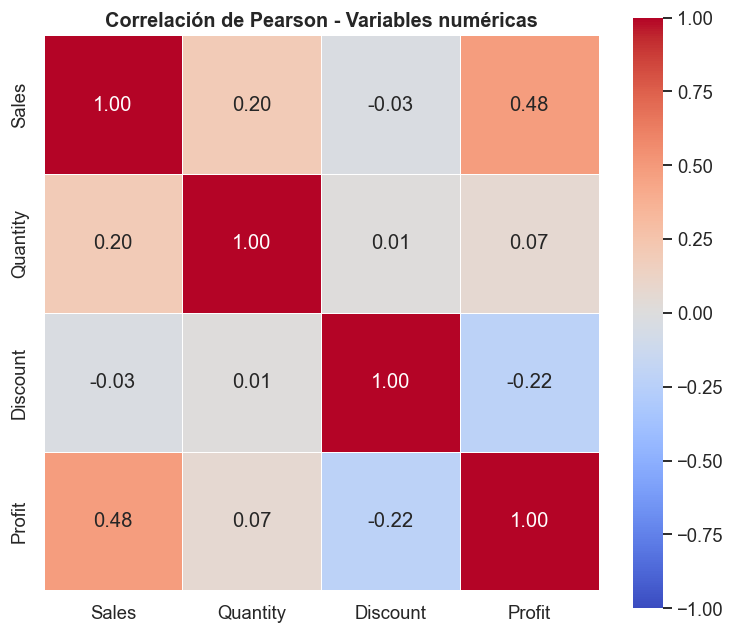

In [12]:
#Heatmap de correlacion de Pearson
#Visión Rápida de todas las realciones lineales entre variables numericas

corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

plt.figure(figsize=(7,6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1, vmax=1
    
)

plt.title('Correlación de Pearson - Variables numéricas')
plt.tight_layout()

plt.show()

Discount <--> Profit = -0.22 : Correlación negativas ---------> más descuento, menos ganancia.

Sales <--> Profit = Correlación positiva moderada ------------> ventas altas tienden a mayor ganancia.

Quantity <--> Profit = Correlación casi nula ----------> Las unidades vendidas no explican nada respecto a profit

Sales <--> Quantity = Correlacion positiva leve ---------> Más unidades, algo más de ventas.

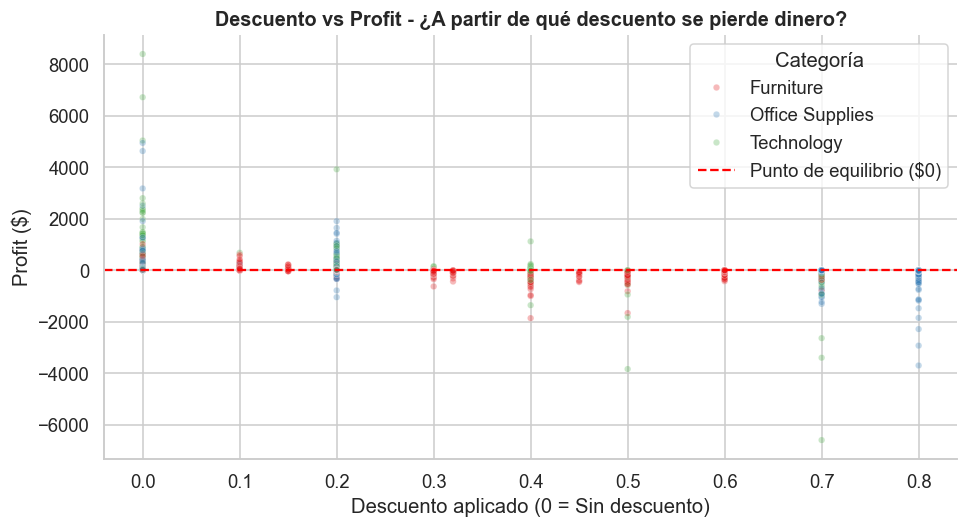

In [13]:
# Scatterplot: Discount vs profit (colreado por categoría)
# Cada punto: Una transacción, los puntos bjao la linea roja son perdidas

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df, x='Discount', y='Profit',
    hue='Category',
    alpha=0.3,
    s=18,
    palette='Set1'
    
)

plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Punto de equilibrio ($0)')
plt.title('Descuento vs Profit - ¿A partir de qué descuento se pierde dinero?')
plt.xlabel('Descuento aplicado (0 = Sin descuento)')
plt.ylabel('Profit ($)')
plt.legend(title='Categoría')
plt.tight_layout()

plt.show()

C:\Users\JORGE\AppData\Local\Temp\ipykernel_13224\3041703333.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Profit', order=orden_cat_profit, palette='muted')


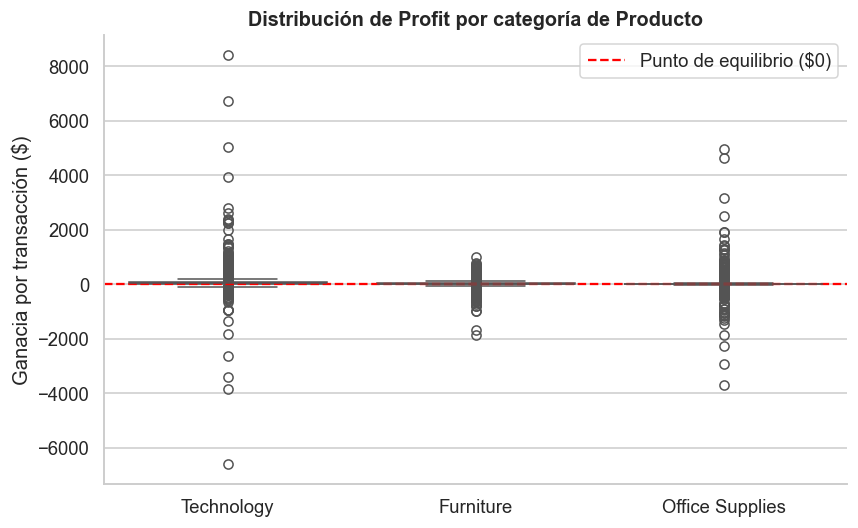

In [14]:
# Boxplot: profit por categoría
plt.figure(figsize=(8, 5))
orden_cat_profit = df.groupby('Category')['Profit'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Category', y='Profit', order=orden_cat_profit, palette='muted')

plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Punto de equilibrio ($0)')
plt.title('Distribución de Profit por categoría de Producto')
plt.xlabel('')
plt.ylabel('Ganacia por transacción ($)')
plt.legend()
plt.tight_layout()

plt.show()

## Correlación != Causalidad

¿Qué significa que dos variables estén correlacionadas?

R//: Siginifica que tienden a cmabiar juntas.

Ejemplo de correalciones sin causalidad.

-Las ventas de Helado correlacionan con los ahogamientos en piscinas. ¿El helado mata? : NO: El calor del verano causa ambas.

-Los países con más televisores tienen mayor esperanza de vida. ¿Ver TV alarga la vida?: NO: La riqueza causa ambas.

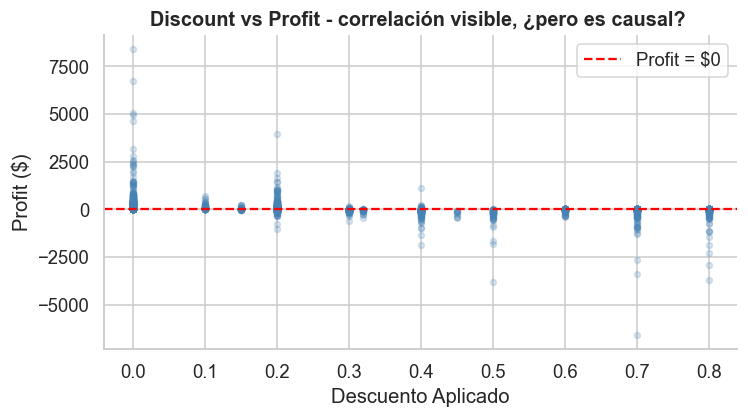

In [16]:
#Visualizacipon de lo que es la correlacion del descuento y el profit

fig, ax = plt.subplots(figsize=(7,4))

ax.scatter(
    df['Discount'], df['Profit'],
    alpha=0.2,  #transparencia para ver las densidades con 9994 puntos
    s=15,   #Tamañao de cada punto
    color='steelblue'
)

ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Profit = $0')
ax.set_title('Discount vs Profit - correlación visible, ¿pero es causal? ')
ax.set_xlabel('Descuento Aplicado')
ax.set_ylabel('Profit ($)')
ax.legend()
plt.tight_layout()
plt.show()

Vamos a investigar la variables confusora.

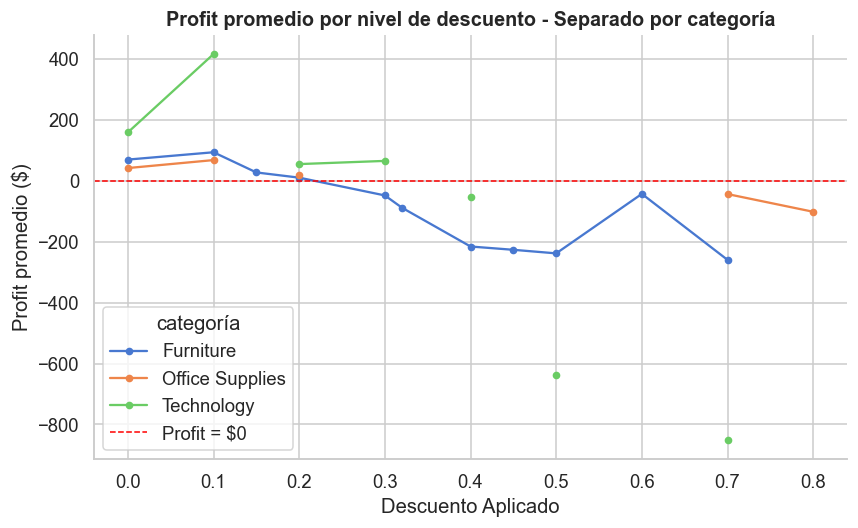

In [21]:
#Agrupar por Categoria y por Descuento para poder ver el profit promedio en cada combinación
#Lo cual esto no va  a permitir ver si el efecto del descuento es igual en todas las categorías.

pivot_cat = df.pivot_table(
    values='Profit',
    index='Discount',
    columns='Category',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(8,5))


#Una linea por categoría: Si las líneas caen de forma diferente, el efecto no es homogéneo

for cat in pivot_cat.columns:
    ax.plot(pivot_cat.index, pivot_cat[cat], marker='o', markersize=4, label=cat)


ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Profit = $0')
ax.set_title('Profit promedio por nivel de descuento - Separado por categoría')
ax.set_xlabel('Descuento Aplicado')
ax.set_ylabel('Profit promedio ($)')
ax.legend(title='categoría')
plt.tight_layout()
plt.show()




El descuento influye en las pérdidas, pero no necesariamente es la única causa.

-Descuento alto, menores ganancias.

El descuento no es la causa directa.

Hay otros factores que afectan el profit como lo son:

-El costo del producto.

-Un descuento mal calculado.

-La cantidad vendida.

-Los costos de envío.

-El tipo de producto.

-La Región etc...